<a href="https://colab.research.google.com/github/manalchem/nanoparticle-size-distribution/blob/main/nanoparticle_size_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Results & Analysis

- **Condition A (Low Temp):** Mean = 86.4 nm, PDI = 0.180 — broad distribution,
  poor size control. Large particles reduce surface area for tissue scaffold integration.

- **Condition B (Mid Temp):** Mean = 45.8 nm, PDI = 0.061 — moderate size with
  improved monodispersity. Suitable for drug loading applications.

- **Condition C (High Temp):** Mean = 20.1 nm, PDI = 0.023 — tight distribution,
  highly monodisperse. Ideal for tissue engineering composites where uniform
  particle size controls mechanical properties and biocompatibility.

### Key Takeaway
Higher synthesis temperature produces smaller, more uniform nanoparticles
(lower PDI). For tissue engineering applications, Condition C offers the best
size control — critical for consistent composite biomaterial performance.

### Relevance to Materials Characterization
PDI (Polydispersity Index) is a standard metric measured by Dynamic Light
Scattering (DLS) in nanoparticle characterization labs. A PDI < 0.1 indicates
a monodisperse, well-controlled synthesis.


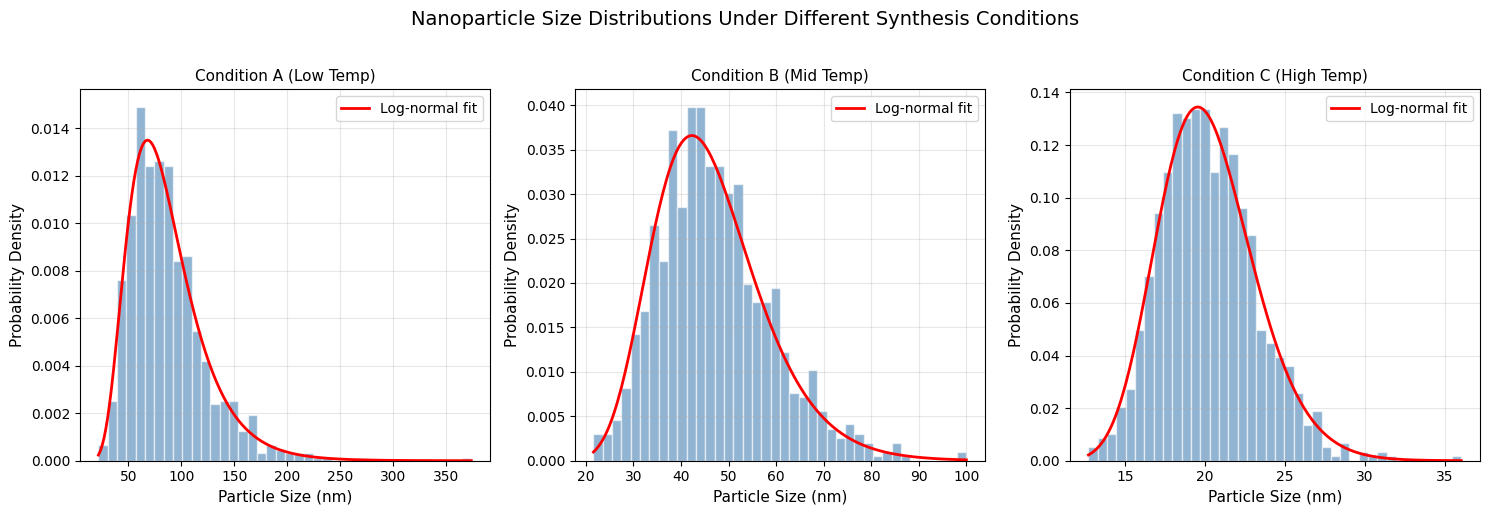

─── Materials Characterization Summary ───
Condition                      Mean (nm)    Std Dev      PDI       
-----------------------------------------------------------------
Condition A (Low Temp)         86.4         36.6         0.180     
Condition B (Mid Temp)         45.8         11.3         0.061     
Condition C (High Temp)        20.1         3.1          0.023     


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Synthesis Parameters ─────────────────────────────────────────
np.random.seed(42)

# Three synthesis conditions (e.g. different temperatures or precursor concentrations)
conditions = {
    'Condition A (Low Temp)':  {'mean': 80,  'sigma': 0.4},
    'Condition B (Mid Temp)':  {'mean': 45,  'sigma': 0.25},
    'Condition C (High Temp)': {'mean': 20,  'sigma': 0.15},
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Nanoparticle Size Distributions Under Different Synthesis Conditions',
             fontsize=14, y=1.02)

for ax, (label, params) in zip(axes, conditions.items()):
    mu = np.log(params['mean'])
    sigma = params['sigma']

    # Generate size distribution
    sizes = np.random.lognormal(mu, sigma, 1000)

    # Plot histogram
    ax.hist(sizes, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white')

    # Overlay theoretical PDF
    x = np.linspace(sizes.min(), sizes.max(), 200)
    pdf = stats.lognorm.pdf(x, s=sigma, scale=np.exp(mu))
    ax.plot(x, pdf, 'r-', linewidth=2, label='Log-normal fit')

    ax.set_xlabel('Particle Size (nm)', fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nanoparticle_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical Summary ───────────────────────────────────────────
print("─── Materials Characterization Summary ───")
print(f"{'Condition':<30} {'Mean (nm)':<12} {'Std Dev':<12} {'PDI':<10}")
print("-" * 65)
for label, params in conditions.items():
    mu = np.log(params['mean'])
    sigma = params['sigma']
    sizes = np.random.lognormal(mu, sigma, 1000)
    mean = np.mean(sizes)
    std = np.std(sizes)
    pdi = (std/mean)**2  # Polydispersity Index
    print(f"{label:<30} {mean:<12.1f} {std:<12.1f} {pdi:<10.3f}")


# Nanoparticle Size Distribution Analysis
## Chemical Engineering Portfolio Project

Nanoparticle size distribution is critical in materials science and tissue engineering —
particle size directly controls surface area, reactivity, drug loading capacity,
and biocompatibility in composite biomaterials.

### This notebook models:
- Log-normal size distributions (the natural distribution of synthesized nanoparticles)
- Effect of synthesis parameters on mean particle size and polydispersity
- Statistical characterization metrics used in materials characterization (DLS, TEM analysis)


In [ ]:
!pip install matplotlib numpy scipy pandas